# Construire un arbre avec `scikit-learn`

 `DecisionTreeClassifier`


In [24]:
import pandas as pd

data = {
    "Jour": range(1, 11),
    "Météo": [
        "Soleil", "Soleil", "Soleil", "Soleil",
        "Nuageux", "Nuageux", "Nuageux",
        "Pluie", "Pluie", "Pluie"
    ],
    "Vent": [
        "Faible", "Faible", "Fort", "Fort",
        "Faible", "Fort", "Fort",
        "Faible", "Faible", "Fort"
    ],
    "Température": [
        28, 23, 31, 27, 19, 29, 25, 22, 30, 26
    ],
    "Jouer": [
        "Oui", "Oui", "Non", "Non",
        "Oui", "Oui", "Oui",
        "Non", "Non", "Oui"
    ]
}

df = pd.DataFrame(data)

df

,Jour,Météo,Vent,Température,Jouer
0,1,Soleil,Faible,28,Oui
1,2,Soleil,Faible,23,Oui
2,3,Soleil,Fort,31,Non
3,4,Soleil,Fort,27,Non
4,5,Nuageux,Faible,19,Oui
5,6,Nuageux,Fort,29,Oui
6,7,Nuageux,Fort,25,Oui
7,8,Pluie,Faible,22,Non
8,9,Pluie,Faible,30,Non
9,10,Pluie,Fort,26,Oui


In [25]:
# Séparer X et y

X = df.drop(columns=["Jour", "Jouer"])
y = df["Jouer"]
# X = variables explicatives
# y = variable à prédire

In [26]:
# Transformer les variables catégorielles
#`DecisionTreeClassifier` ne sait pas directement traiter les chaînes de caractères `"Soleil"`, `"Pluie"`, etc.
# Nous allons utiliser `OneHotEncoder`.

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["Météo", "Vent"]
numeric_features = ["Température"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

In [27]:
# Construire l'arbre

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

In [19]:
# Entraînement

from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("tree", model)
])

pipeline.fit(X, y)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Météo', 'Vent']),
                                                 ('num', 'passthrough',
                                                  ['Température'])])),
                ('tree', DecisionTreeClassifier(random_state=42))])

In [28]:
# Faire une prédiction

# Imaginons une nouvelle journée :
# > Météo = Soleil
# > Vent = Faible
# > Température = 29 °C

nouvelle_journee = pd.DataFrame({
    "Météo": ["Soleil"],
    "Vent": ["Faible"],
    "Température": [29]
})

prediction = pipeline.predict(nouvelle_journee)

print(prediction)

['Oui']


In [ ]:
# Récupérer l'arbre contenu dans le pipeline
tree = pipeline.named_steps["tree"]
# Noms des variables après transformation 
feature_names = pipeline.named_steps["preprocessing"].get_feature_names_out()

print(feature_names)

['cat__Météo_Nuageux' 'cat__Météo_Pluie' 'cat__Météo_Soleil'
 'cat__Vent_Faible' 'cat__Vent_Fort' 'num__Température']


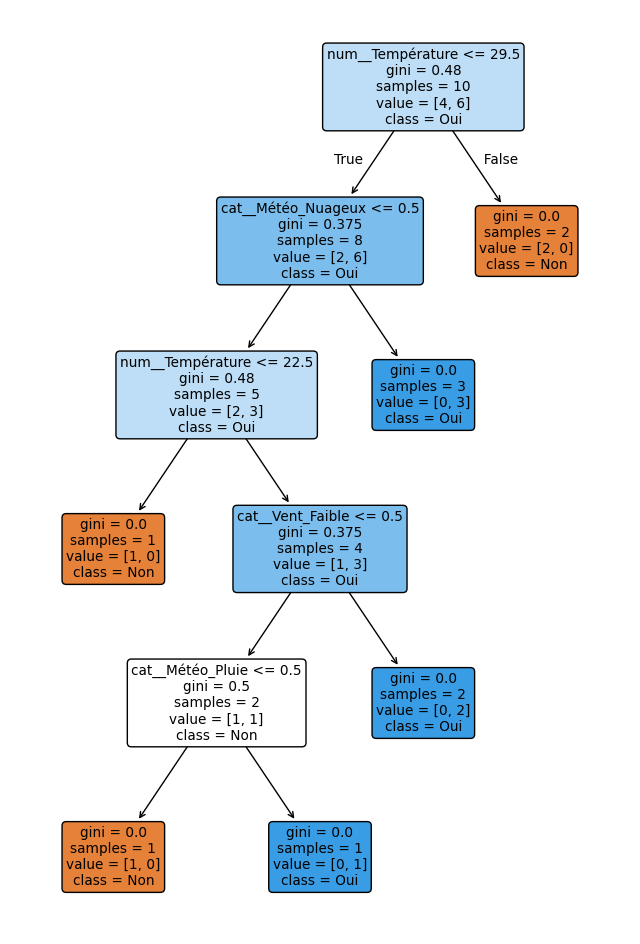

In [34]:
# Visualiser l'arbre


from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 12))

plot_tree(
    tree,
    feature_names=feature_names,
    class_names=tree.classes_,
    filled=True,
    rounded=True
)

plt.show()

Comprendre `gini`, `samples`, `value` et `class`

Supposons que l'on rencontre un nœud affichant :

```text
gini = 0.48
samples = 10
value = [4, 6]
class = Oui
```

On peut le lire ainsi.

- `samples = 10` : le nœud contient $10$ observations.
- `value = [4, 6]`: il y a $4\ Non$ et $6\ Oui$
- `class = Oui`: la classe majoritaire est `Oui`.
- `gini = 0.48` : $Gini=
1-\left(\frac4{10}\right)^2
-\left(\frac6{10}\right)^2$=1-0.16-0.36$


In [ ]:
tree.tree_.threshold
# La valeur -2 a une signification particulière (ce n'est pas un seuil ): le nœud est une feuille.

array([29.5,  0.5, 22.5, -2. ,  0.5,  0.5, -2. , -2. , -2. , -2. , -2. ])

In [32]:
importance = pd.DataFrame({
    "Variable": feature_names,
    "Importance": tree.feature_importances_
})

importance.sort_values(
    "Importance",
    ascending=False
)

,Variable,Importance
5,num__Température,0.562500
1,cat__Météo_Pluie,0.208333
0,cat__Météo_Nuageux,0.125000
3,cat__Vent_Faible,0.104167
2,cat__Météo_Soleil,0.000000
4,cat__Vent_Fort,0.000000


> L'importance d'une variable dans un arbre n'est pas une preuve de causalité.

Elle indique essentiellement à quel point les séparations utilisant cette variable ont contribué à réduire l'impureté pendant la construction de l'arbre.

Contrôler la croissance de l'arbre

Avec seulement 10 observations, notre arbre peut très facilement apprendre parfaitement les données d'entraînement.

C'est ce qu'on appelle le **surapprentissage (overfitting)**.

On peut limiter la complexité de l'arbre.

Par exemple :

```python
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)
```

Ici `max_depth=3` signifie que l'arbre ne pourra pas avoir plus de trois niveaux de profondeur.

On peut également utiliser `min_samples_split=2` ou `min_samples_leaf=2`
